In [137]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
%matplotlib inline
from sklearn import tree

from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor



In [138]:
df=pd.read_csv('data/studper.csv')

In [139]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [140]:
x=df.drop(columns=['math score'])

In [141]:
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [142]:
y=df['math score']

In [143]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [144]:
num_features=x.select_dtypes(exclude="object").columns
cat_features=x.select_dtypes(include="object").columns

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(handle_unknown="ignore")

preprocessing=ColumnTransformer(
    [
        ("OneHotEncoder" , oh_transformer , cat_features ),
        ("StandardScaler" , numeric_transformer , num_features ),
    ]
)

In [145]:
x=preprocessing.fit_transform(x)

In [146]:
print(x)

[[ 1.          0.          0.         ...  1.          0.19399858
   0.39149181]
 [ 1.          0.          0.         ...  0.          1.42747598
   1.31326868]
 [ 1.          0.          0.         ...  1.          1.77010859
   1.64247471]
 ...
 [ 1.          0.          0.         ...  0.          0.12547206
  -0.20107904]
 [ 1.          0.          0.         ...  0.          0.60515772
   0.58901542]
 [ 1.          0.          0.         ...  1.          1.15336989
   1.18158627]]


In [147]:
x.shape


(1000, 19)

In [148]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [149]:
x_train.shape,x_test.shape

((800, 19), (200, 19))

In [150]:
def evaluated_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    r2_sq=r2_score(true,predicted)
    return mae, mse,rmse,r2_sq

In [155]:
models={
    "linear regression":LinearRegression(),
    "lasso ":Lasso(),
    "Ridge":Ridge(),
    "knn reg":KNeighborsRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestregressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=False),
    "AdaBoostRegressor":AdaBoostRegressor()
}
model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)

    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

    model_train_mae,model_train_rmse,model_train_r2,model_train_mse=evaluated_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2,model_test_mse=evaluated_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('model performance for training set')
    print("- root mean squared error : {:.4f}".format(model_train_rmse))
    print("- mean squared error : {:.4f}".format(model_train_mse))
    print("- mean absolute error : {:.4f}".format(model_train_mae))
    print("- r2_score : {:.4f}".format(model_train_r2))

    print('-----------------------------------------------------------------')


    print('model performance for testing set')
    print("- root mean squared error : {:.4f}".format(model_test_rmse))
    print("- mean squared error : {:.4f}".format(model_test_mse))
    print("- mean absolute error : {:.4f}".format(model_test_mae))
    print("- r2_score : {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')



linear regression
model performance for training set
- root mean squared error : 28.3349
- mean squared error : 0.8743
- mean absolute error : 4.2667
- r2_score : 5.3231
-----------------------------------------------------------------
model performance for testing set
- root mean squared error : 29.0952
- mean squared error : 0.8804
- mean absolute error : 4.2148
- r2_score : 5.3940


lasso 
model performance for training set
- root mean squared error : 43.4784
- mean squared error : 0.8071
- mean absolute error : 5.2063
- r2_score : 6.5938
-----------------------------------------------------------------
model performance for testing set
- root mean squared error : 42.5064
- mean squared error : 0.8253
- mean absolute error : 5.1579
- r2_score : 6.5197


Ridge
model performance for training set
- root mean squared error : 28.3378
- mean squared error : 0.8743
- mean absolute error : 4.2650
- r2_score : 5.3233
-----------------------------------------------------------------
model per

In [160]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(x_train,y_train)
y_pred=lin_model.predict(x_test)
score=r2_score(y_test,y_pred)
print("@accuracy of the model Is ", 100*score)


@accuracy of the model Is  88.04332983749565


Text(0, 0.5, 'predicated')

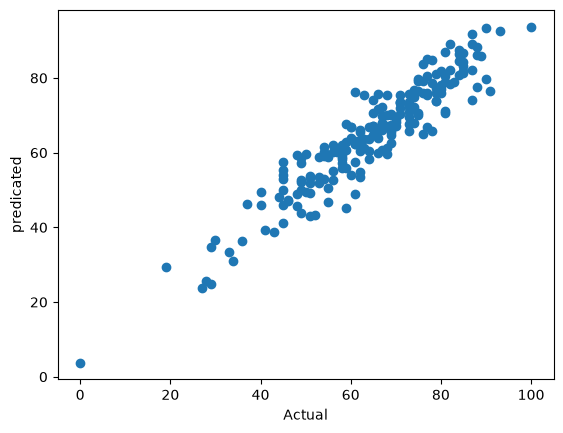

In [161]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('predicated')

<Axes: xlabel='math score'>

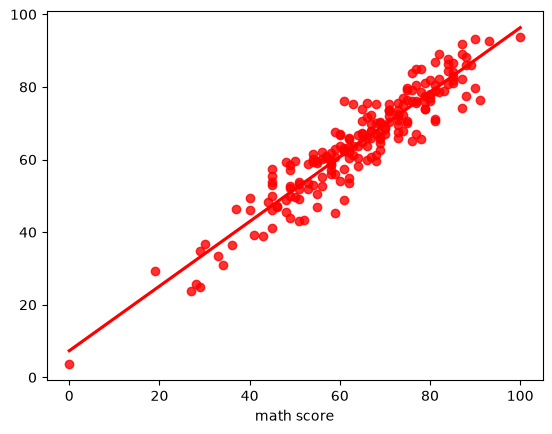

In [ ]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')#bestfit line

In [163]:
pred_df=pd.DataFrame({'Actual value ':y_test,'predictaed':y_pred,'diffrence':y_test-y_pred})
pred_df

,Actual value,predictaed,diffrence
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
